In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn import datasets

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
housing_df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
housing_df['HousePrice'] = housing.target
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Check for missing values in the DataFrame
housing_df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HousePrice,0


In [5]:
# Generate descriptive statistics for the DataFrame
housing_df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


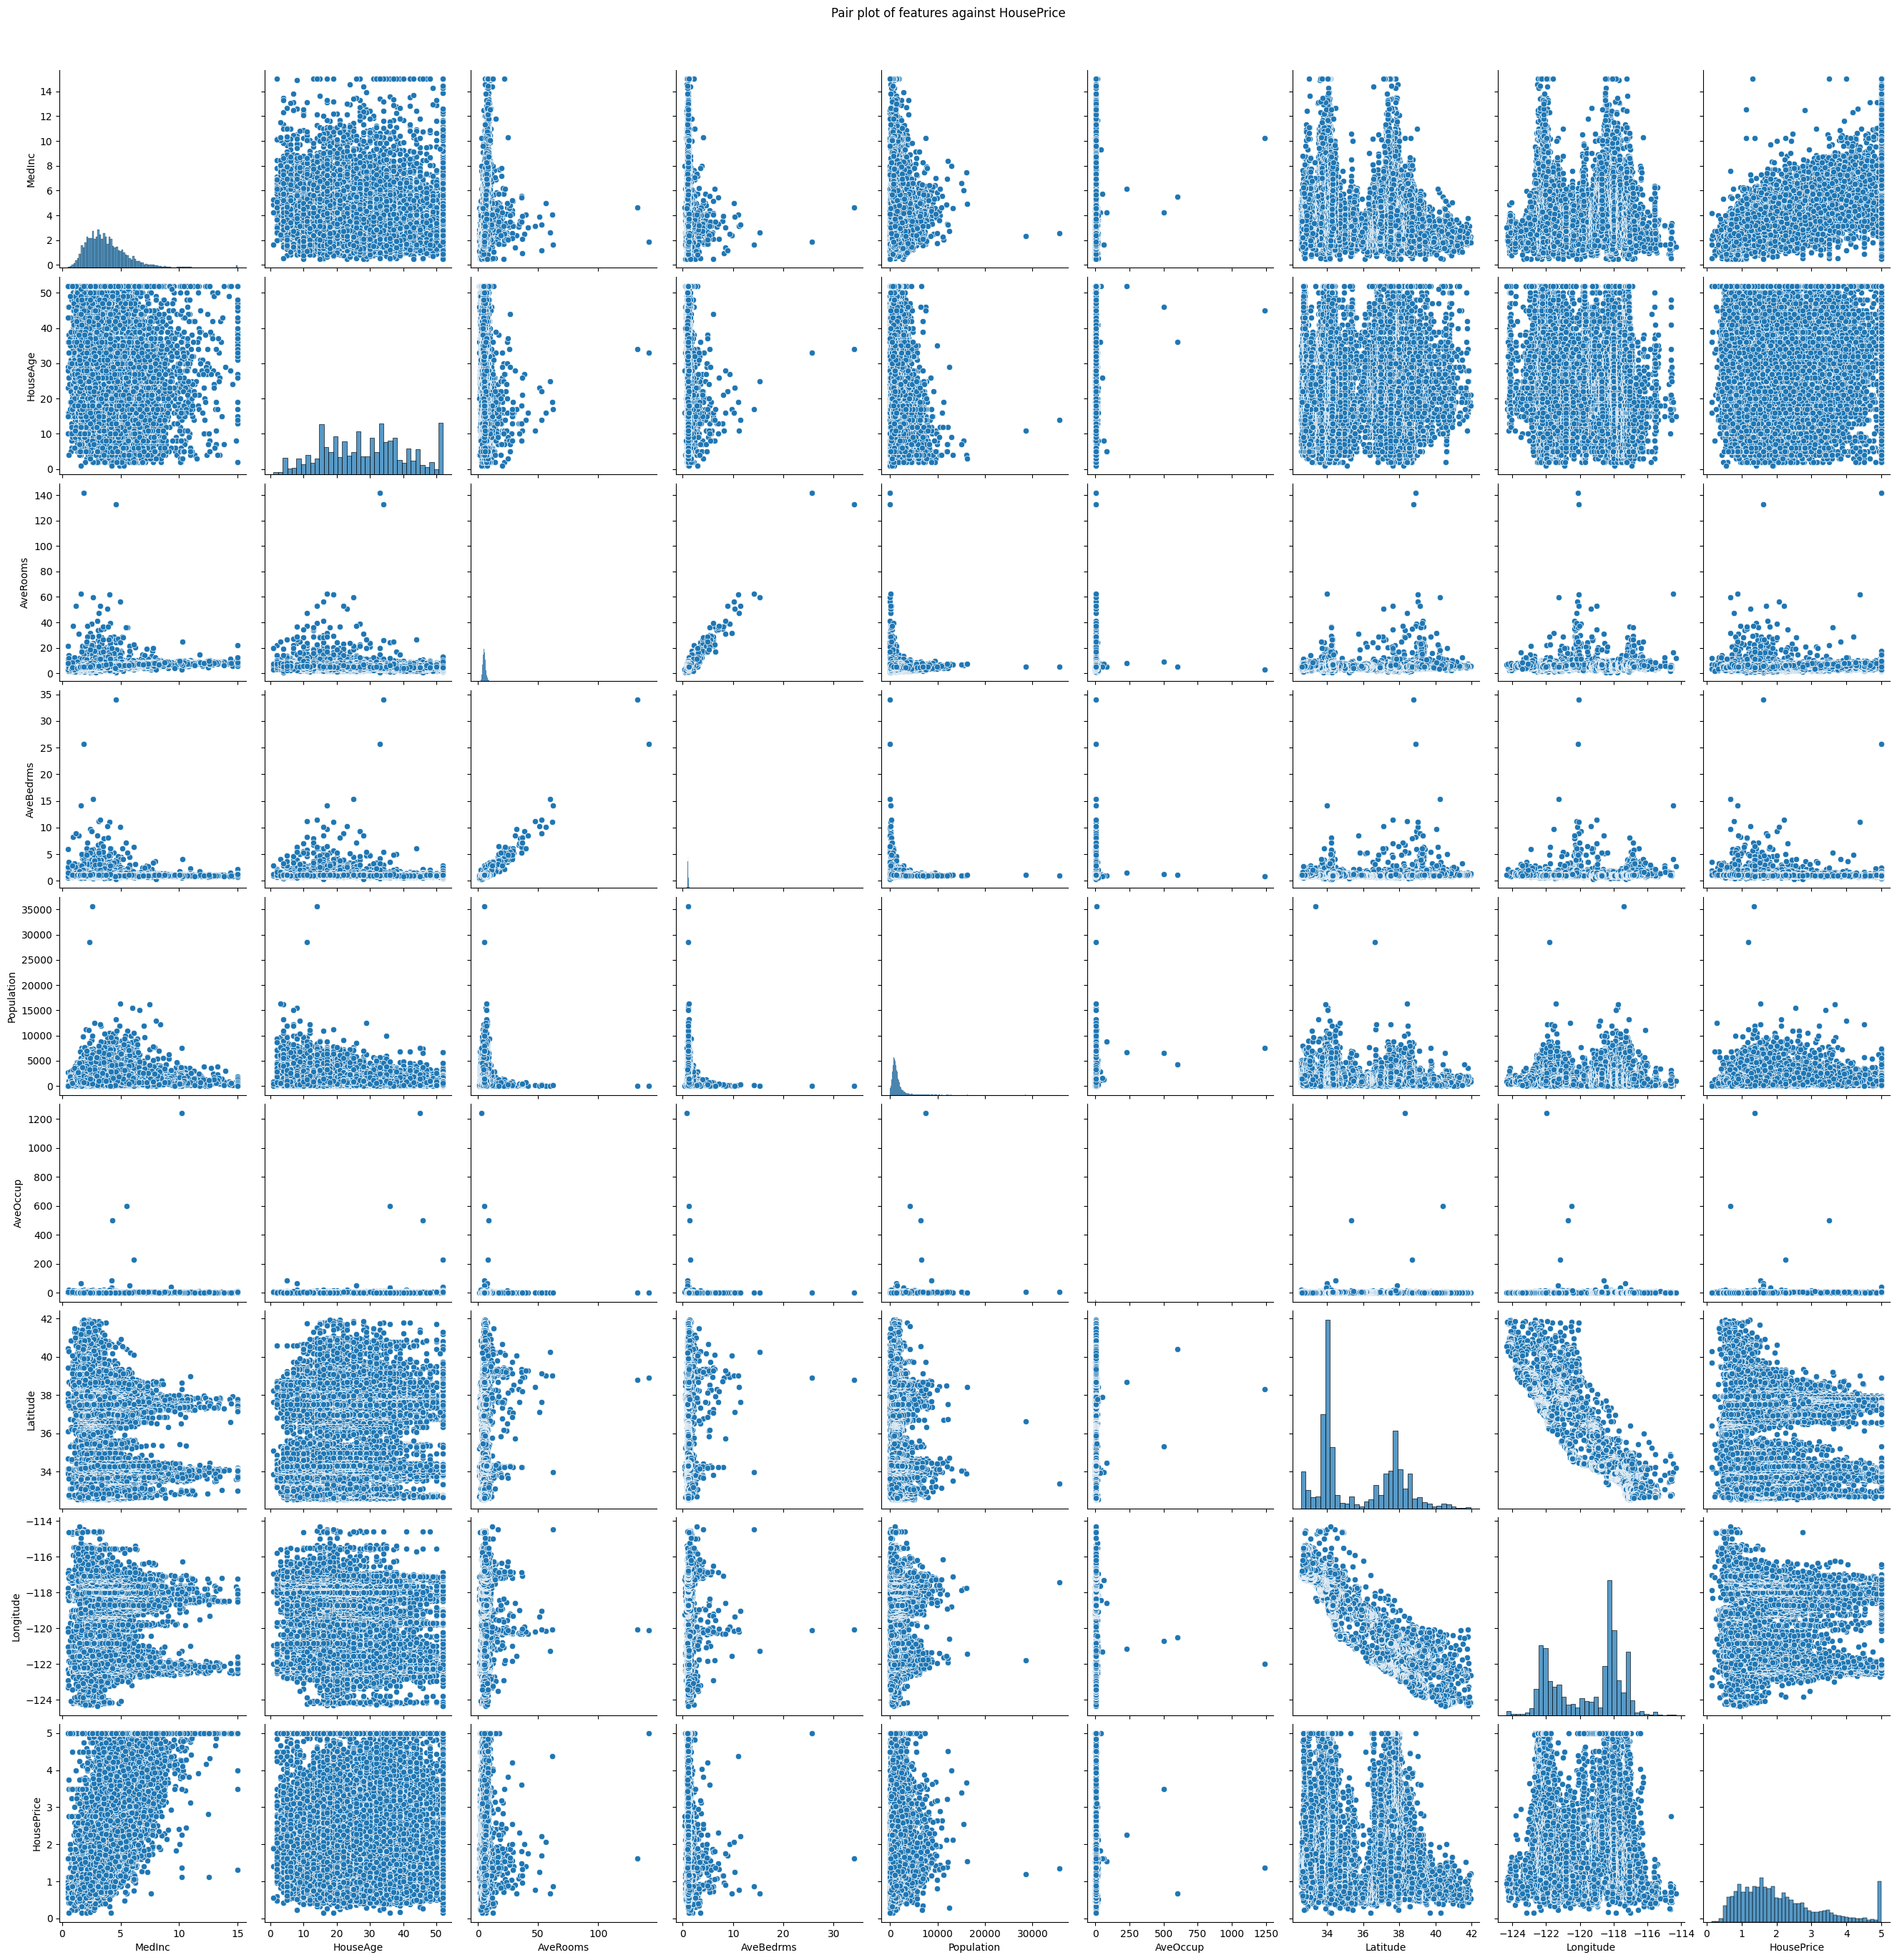

In [6]:
# Create a pair plot of features against HousePrice
sns.pairplot(housing_df, height=3)
plt.suptitle('Pair plot of features against HousePrice', y=1.02)
plt.show()

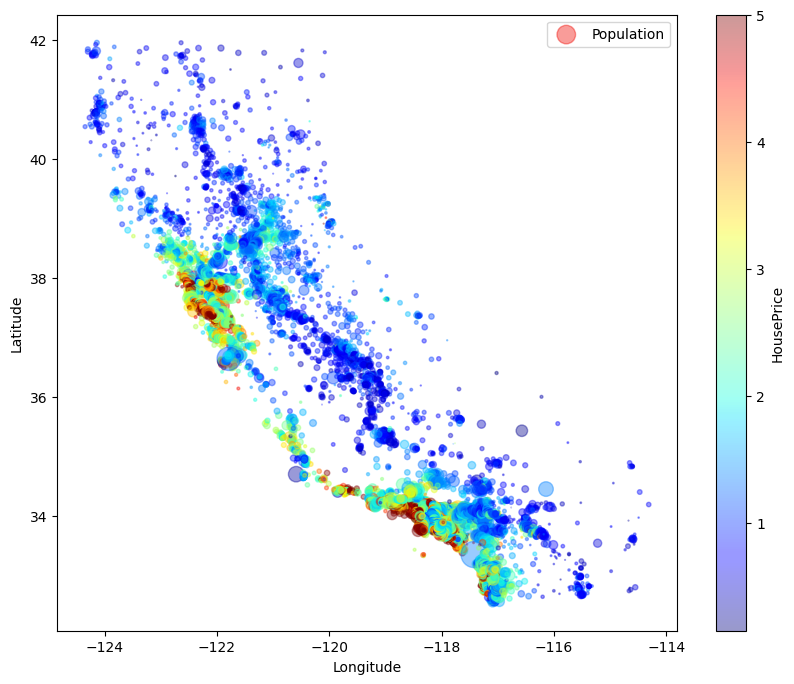

In [7]:
housing_df.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    alpha=0.4,
    s=housing_df['Population']/100,
    label="Population",
    c="HousePrice",
    cmap="jet",
    colorbar=True,
    figsize=(10,8)
)
plt.show()

<Axes: >

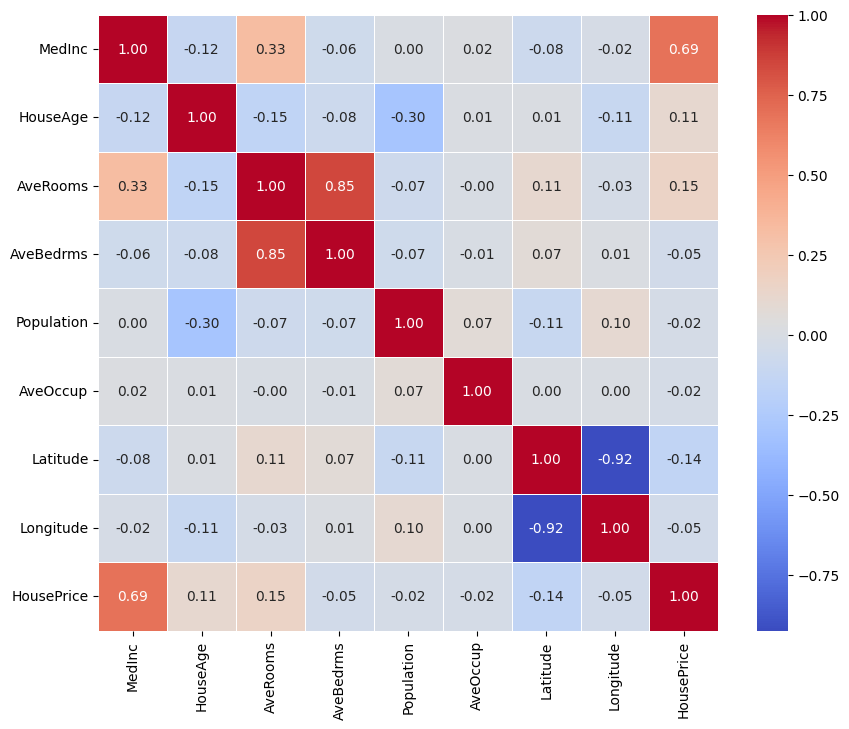

In [8]:
corr=housing_df.corr()
plt.figure(figsize=(10,8))

sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f",linewidth=0.5)

In [9]:
corr["HousePrice"].abs().sort_values(ascending=False)

,HousePrice
HousePrice,1.000000
MedInc,0.688075
AveRooms,0.151948
Latitude,0.144160
HouseAge,0.105623
AveBedrms,0.046701
Longitude,0.045967
Population,0.024650
AveOccup,0.023737


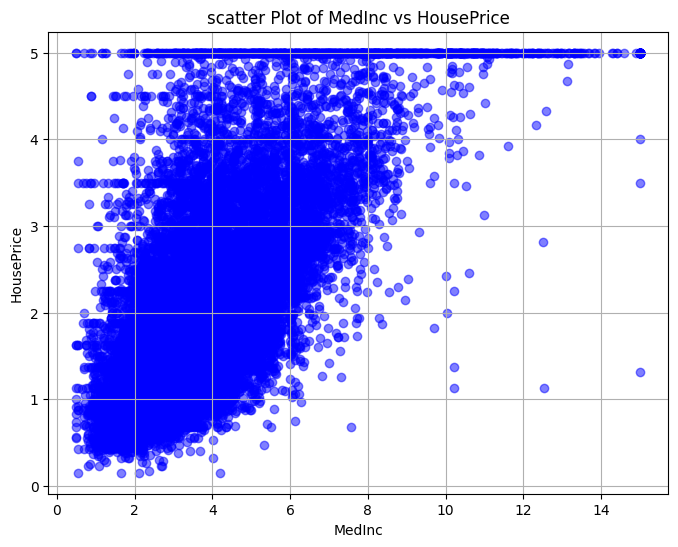

In [10]:
medinc = housing_df['MedInc']
houseprice = housing_df['HousePrice']
plt.figure(figsize=(8,6))
plt.scatter(medinc,houseprice,alpha=0.5,color='blue')
plt.title('scatter Plot of MedInc vs HousePrice')
plt.xlabel('MedInc')
plt.ylabel('HousePrice')
plt.grid(True)
plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop the target variable
housing_df_vif = housing_df.drop('HousePrice', axis=1)

# Convert columns to numeric
housing_df_vif = housing_df_vif.apply(pd.to_numeric, errors='coerce')

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = housing_df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(housing_df_vif.values, i) for i in range(len(housing_df_vif.columns))]

# Display the VIF values
print(vif_data)

      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


In [13]:
housing_df = housing_df.drop(['Latitude', 'Longitude'], axis=1)


In [14]:
cols_to_convert =['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup']
housing_df[cols_to_convert]=housing_df[cols_to_convert].apply(pd.to_numeric,errors='coerce')
housing_df['HousePrice']=pd.to_numeric(housing_df['HousePrice'],errors='coerce')

x=sm.add_constant(housing_df.drop('HousePrice',axis=1))
y=housing_df['HousePrice']

model =sm.OLS(y,x).fit()

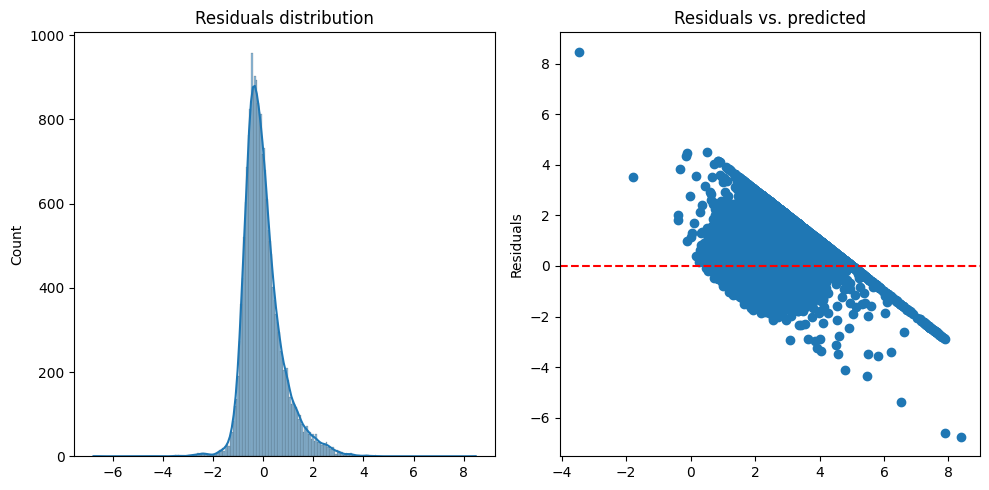

Model coefficients:
 const        -0.439093
MedInc        0.536910
HouseAge      0.016503
AveRooms     -0.211740
AveBedrms     0.993730
Population    0.000022
AveOccup     -0.004877
dtype: float64


In [18]:
residuals = model.resid

plt.figure(figsize=(10, 5))  # Corrected from `figuresize` to `figsize`

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Residuals distribution')  # Corrected spelling from 'Residuls' to 'Residuals'

plt.subplot(1, 2, 2)
plt.scatter(model.predict(x), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. predicted')  # Corrected spelling from 'Residuls' to 'Residuals'
plt.ylabel('Residuals')  # Corrected from `plt.ylabl` to `plt.ylabel`

plt.tight_layout()  # Ensures proper spacing between subplots
plt.show()

print("Model coefficients:\n", model.params)  # Corrected spelling from 'coefficient' to 'coefficients'


In [22]:
from sklearn.metrics import mean_squared_error, r2_score
predictions = model.predict(x)

print("R square Score:", r2_score(y, predictions))
print("MSE:", mean_squared_error(y, predictions))


R square Score: 0.5396977345638283
MSE: 0.6129156196698703


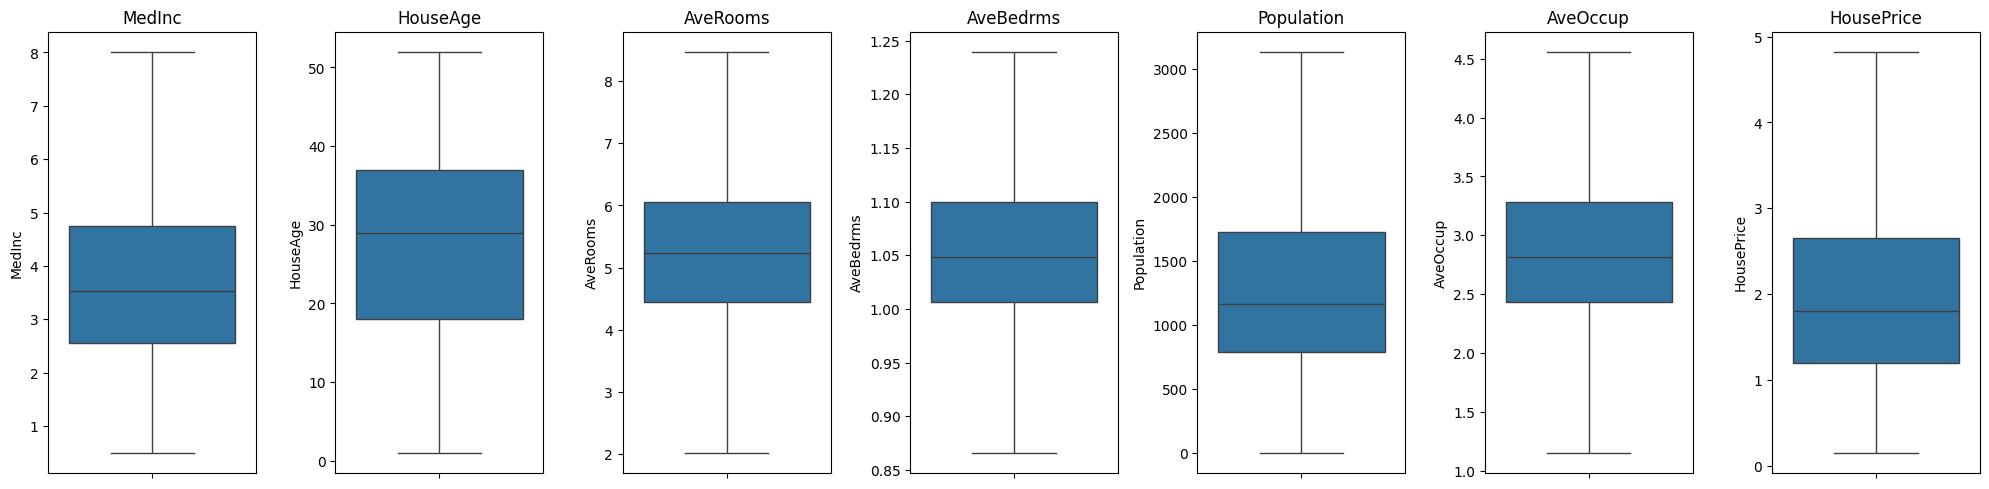

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def remove_outliers(df):
    df_no_outliers = df.copy()

    for column_name in df.columns:
        if pd.api.types.is_numeric_dtype(df[column_name]):
            Q1 = df[column_name].quantile(0.25)
            Q3 = df[column_name].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            df_no_outliers[column_name] = df_no_outliers[column_name].apply(
                lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
            )

    return df_no_outliers

def plot_boxplots(df):
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])

    # Create subplots
    fig, axes = plt.subplots(1, len(numeric_df.columns), figsize=(20, 5))

    # Plot box plots for each numeric column
    for i, column_name in enumerate(numeric_df.columns):
        sns.boxplot(y=numeric_df[column_name], ax=axes[i])
        axes[i].set_title(column_name)

    plt.tight_layout()
    plt.show()

# Assuming housing_df is already defined and loaded
housing_df_new = remove_outliers(housing_df)
plot_boxplots(housing_df_new)


In [31]:
cols_to_convert = ['MedInc' , 'HouseAge','AveBedrms','Population','AveOccup']
housing_df_new[cols_to_convert] = housing_df_new[cols_to_convert].apply(pd.to_numeric,errors='coerce')
housing_df_new['HousePrice'] = pd.to_numeric(housing_df_new['HousePrice'],errors='coerce')

X= sm.add_constant(housing_df_new.drop('HousePrice',axis=1))
Y=housing_df_new['HousePrice']

model = sm.OLS(Y,X).fit()

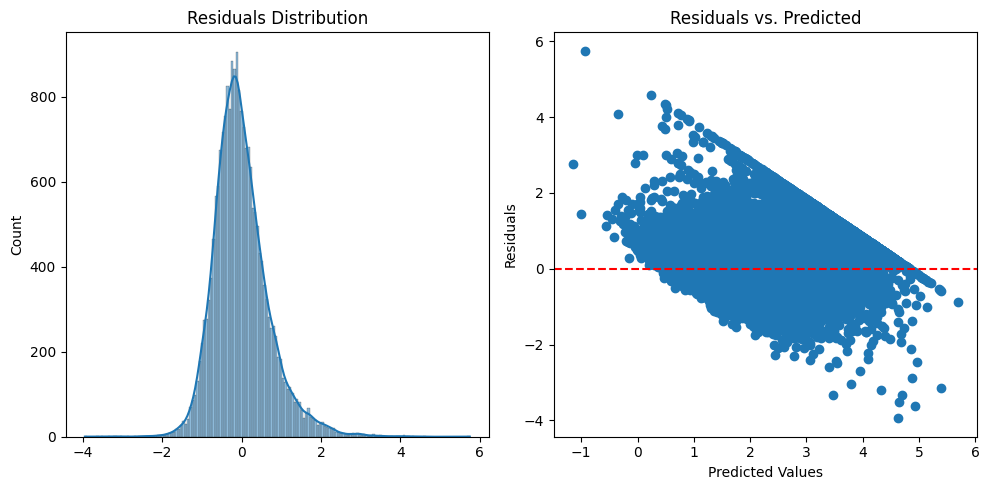

Model coefficients:
 const        -1.025744
MedInc        0.634138
HouseAge      0.018696
AveRooms     -0.258632
AveBedrms     2.308808
Population    0.000079
AveOccup     -0.357348
dtype: float64


In [32]:
residuals = model.resid

plt.figure(figsize=(10, 5))

# First subplot: Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')

# Second subplot: Scatter plot of residuals vs. predicted values
plt.subplot(1, 2, 2)
plt.scatter(model.predict(X), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()  # Ensures proper spacing between subplots
plt.show()

print("Model coefficients:\n", model.params)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
predictions = model.predict(x)
# X est la matrice des variables indépendantes (avec une constante ajoutée)
# Y est le vecteur des variables dépendantes
print("R square Score:", r2_score(y,predictions))
print("MSE:",mean_squared_error(y,predictions))

R square Score: -9.709505966528011
MSE: 14.260245883458282


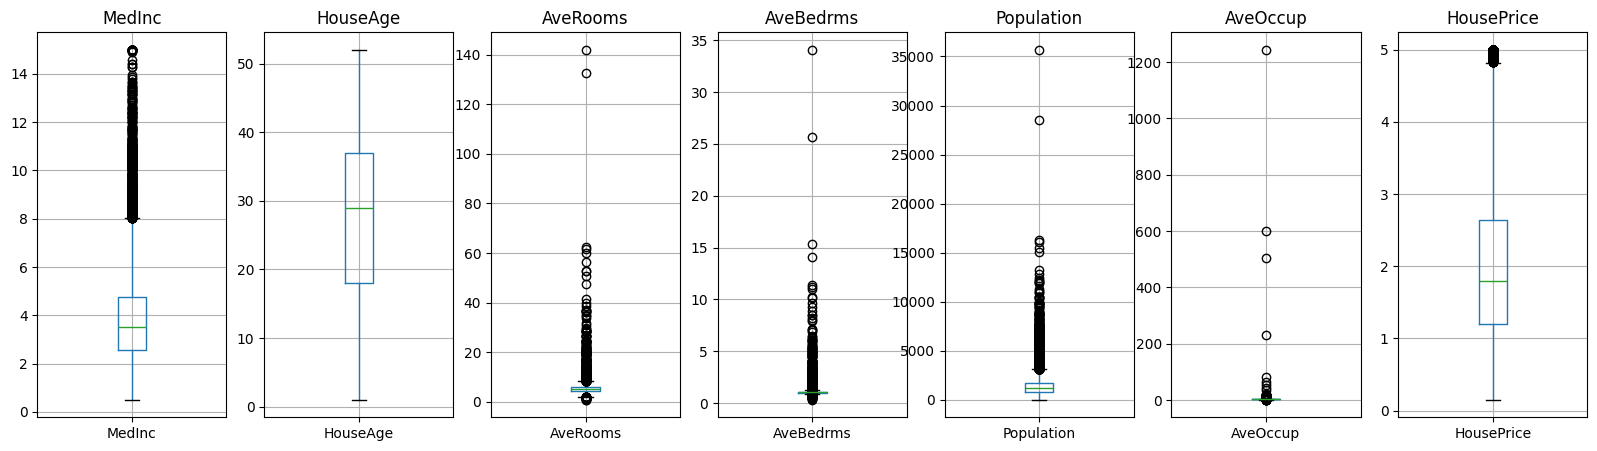

In [38]:
import matplotlib.pyplot as plt
def plot_boxplots(df):
    fig, axes=plt.subplots(1,len(df.columns), figsize=(20,5))

    for i,column_name in enumerate(df.columns):
        df.boxplot(column=column_name,ax=axes[i])
        axes[i].set_title(column_name)
plt.show()
plot_boxplots(housing_df)

In [40]:
def remove_outliers(df):
    df_no_outliers = df.copy()

    for column_name in df.columns:
        Q1=df[column_name].quantile(0.25)
        Q3=df[column_name].quantile(0.75)
        IQR = Q3 -Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 *IQR

        df_no_outliers[column_name] = df_no_outliers[column_name].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
        return df_no_outliers

    housing_df_new = remove_outliers(housing_df)

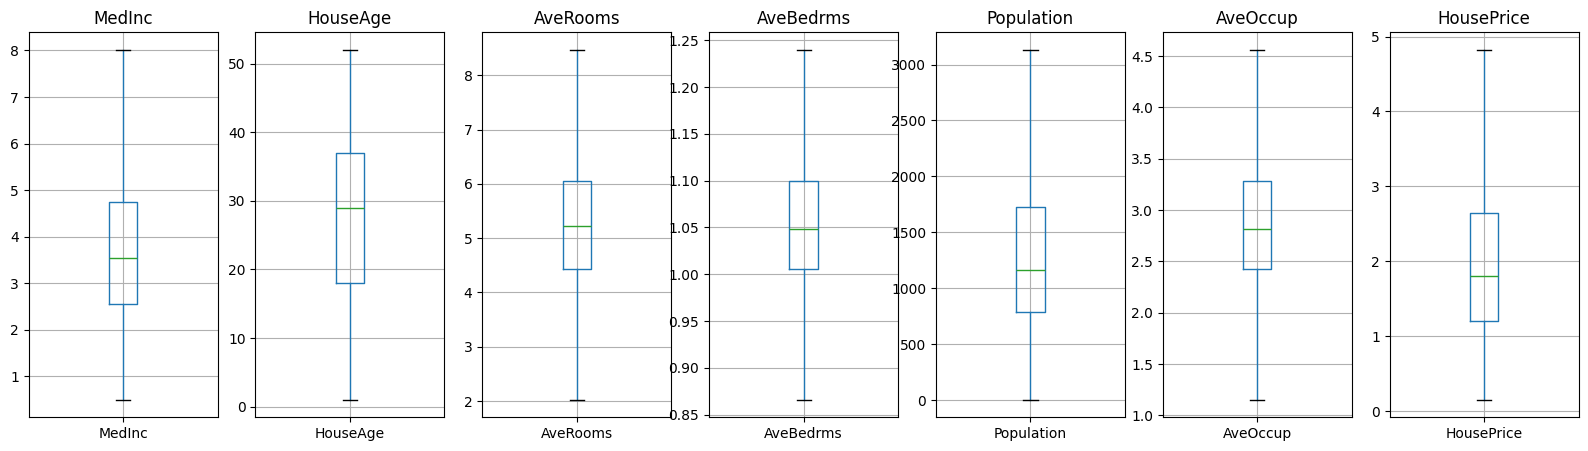

In [41]:
plot_boxplots(housing_df_new)

In [42]:
cols_to_convert = ['MedInc' , 'HouseAge','AveBedrms','Population','AveOccup']
housing_df_new[cols_to_convert] = housing_df_new[cols_to_convert].apply(pd.to_numeric,errors='coerce')
housing_df_new['HousePrice'] = pd.to_numeric(housing_df_new['HousePrice'],errors='coerce')

X= sm.add_constant(housing_df_new.drop('HousePrice',axis=1))
Y=housing_df_new['HousePrice']

model = sm.OLS(Y,X).fit()

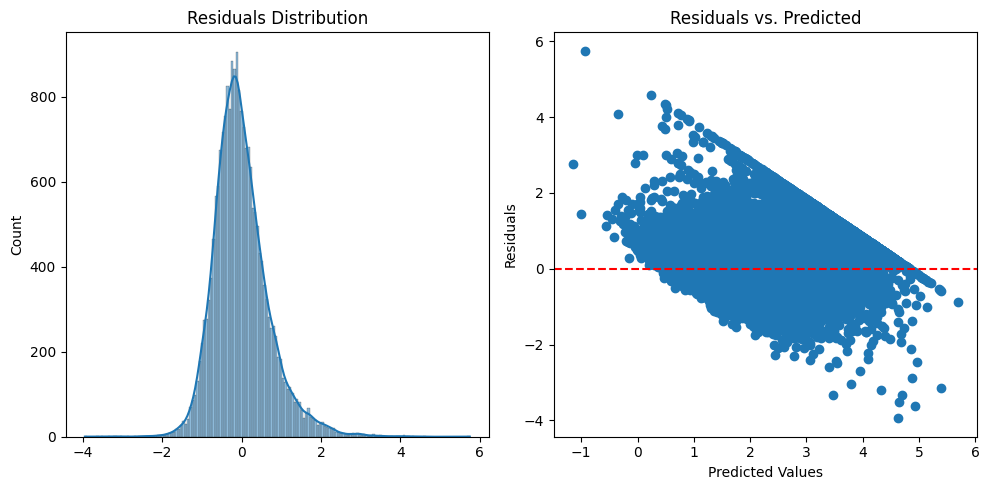

Model coefficients:
 const        -1.025744
MedInc        0.634138
HouseAge      0.018696
AveRooms     -0.258632
AveBedrms     2.308808
Population    0.000079
AveOccup     -0.357348
dtype: float64


In [43]:
residuals = model.resid

plt.figure(figsize=(10, 5))

# First subplot: Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')

# Second subplot: Scatter plot of residuals vs. predicted values
plt.subplot(1, 2, 2)
plt.scatter(model.predict(X), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()  # Ensures proper spacing between subplots
plt.show()

print("Model coefficients:\n", model.params)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = model.predict(X)

print("R square score:" ,r2_score(y, predictions))
print("MSE:" , mean_squared_error(y,predictions))

R square score: 0.615972739377477
MSE: 0.5113516141215152
